In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [26]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')


In [27]:
df = pd.read_csv("../data/raw/churn_data.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
print(f"Total Rows in dataset: {df.shape[0]}")
print(f"Total Columns in dataset: {df.shape[1]}\n")

df.info()

Total Rows in dataset: 7043
Total Columns in dataset: 21

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    


In [29]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- dataset has 7043 rows and 21 columns
- there are no null values in the dataset

In [33]:
df.duplicated().sum()

np.int64(0)

In [38]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [39]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [42]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [45]:
df["MultipleLines"].value_counts()
df["InternetService"].value_counts()
df["Contract"].value_counts()
df["PaymentMethod"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

Text(0.5, 1.0, 'Customer Churn Distibution')

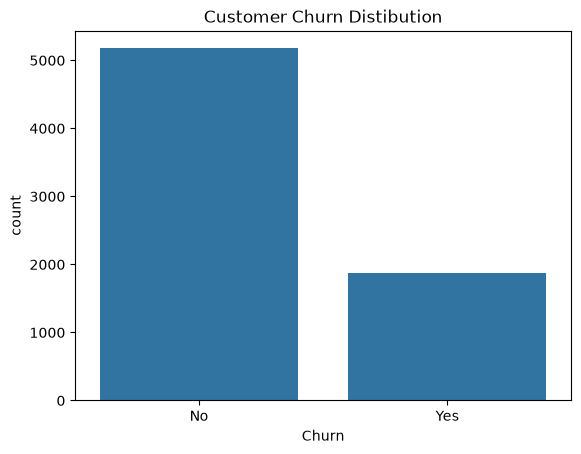

In [49]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distibution")
plt.show()

- The dataset contains more non-churned customers (5,174) than churned customers (1,869). Approximately 26.5% of customers have churned, indicating an imbalanced target variable.

<Axes: xlabel='Contract', ylabel='count'>

Text(0.5, 1.0, 'Churn by Contract type')

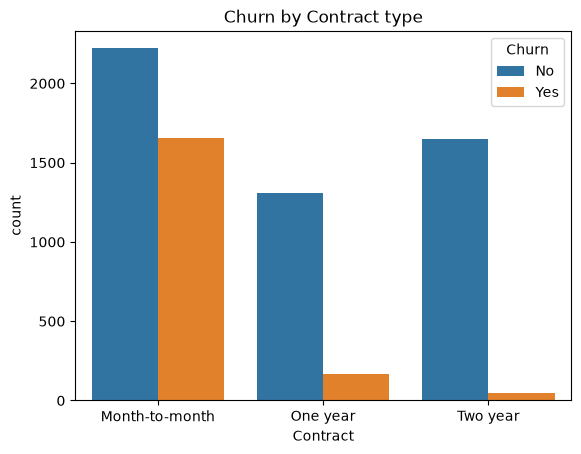

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract type")
# plt.xticks(rotation=20)
plt.show()

- Month-to-month contracts have the highest number of churned customers.
- One-year contracts have considerably fewer churned customers than month-to-month contracts.
- Two-year contracts have the lowest number of churned customers.
- There is a clear decrease in churn counts as the contract duration increases

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

Text(0.5, 1.0, 'Monthly Charges by Churn Status')

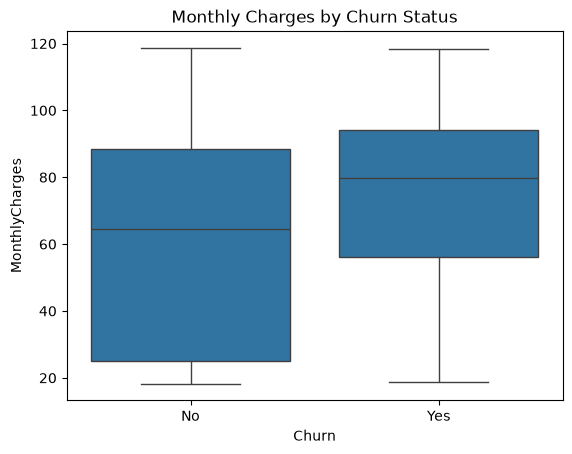

In [58]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

- the median monthly charge is approximately $65 for customers who did not churn and $80 for customers who churned. this shows customers who churned tend to have higher monthly charges than customers who do not churn.

- middle 50% of the customers who have churned is shifted upwards -> 50% of the churned customers generally have higher monthly charges compared to non-churned customers.

- For churned customers, approximately 25% have monthly charges below $56 and 25% have charges above $94

- For non-churned customers, approximately 25% have charges below $25 and 25% have charges above $88.

- This suggests that higher monthly charges are associated with churn, although monthly charges alone cannot determine whether a customer will churn.

In [69]:
churn_rate = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
print(churn_rate)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


<Axes: xlabel='Contract'>

Text(0.5, 1.0, 'Churn Rate by Contract Type')

Text(0.5, 0, 'Contract Type')

Text(0, 0.5, 'Churn Rate (%)')

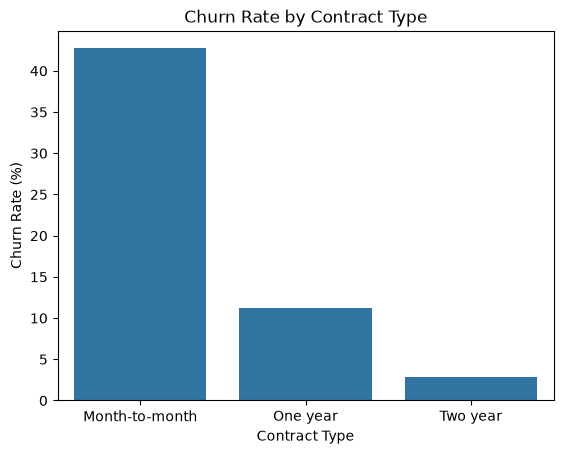

In [71]:
sns.barplot(x=churn_rate.index, y=churn_rate.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

- Churn rate is substantially higher among month-to-month customers (~43%) than among one-year (~11%) and two-year (~3%) customers. This indicates that shorter contract duration is strongly associated with higher customer churn.

In [ ]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

<Axes: xlabel='Churn', ylabel='tenure'>

Text(0.5, 1.0, 'Tenure by Churn status')

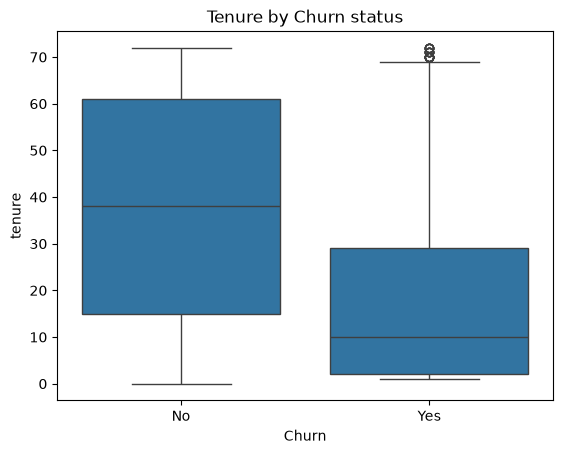

In [89]:
# plt.figure(figsize=(10,10))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn status")
plt.show()

- the median tenure for churned customers is ~10 months while that for non-churned customers is ~38
- the middle 50% customers who have churned is shifted downwards -> 50% of the churned customers generally have low tenure compared to non-churned customers
- there is still overlap so this suggests that lower tenure are associated with churn, although tenure alone cannot determine whether a customer will churn.
- A few churned customers have unusually high tenure and appear as potential outliers in the boxplot.

<Axes: xlabel='InternetService', ylabel='count'>

Text(0.5, 1.0, 'Churn by Internet Service')

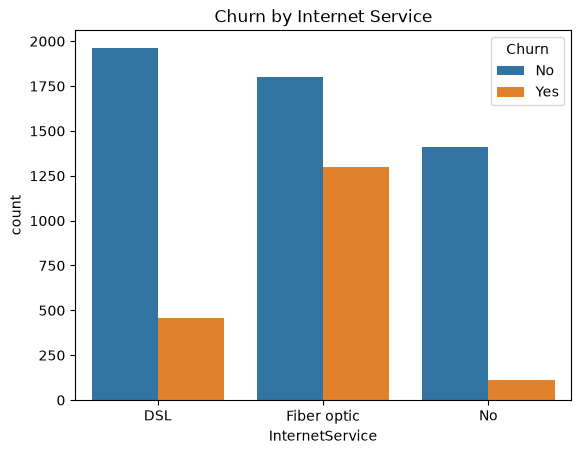

In [90]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

<Axes: xlabel='PaymentMethod', ylabel='count'>

Text(0.5, 1.0, 'Churn by Payment method')

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

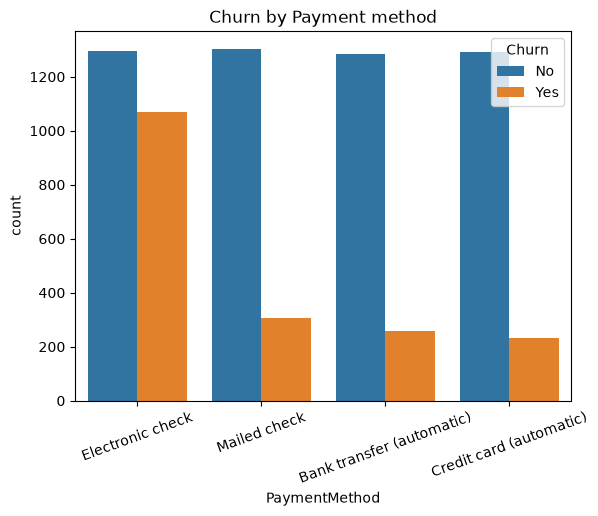

In [92]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment method")
plt.xticks(rotation=20)

plt.show()